### A MNIST-like fashion product database

In this, we classify the images into respective classes given in the dataset. We use a Neural Net and a Deep Neural Net in Keras to solve this and check the accuracy scores.

### Load tensorflow

In [0]:
import tensorflow as tf
tf.set_random_seed(42)

In [0]:
import numpy as np
import pandas as pd
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers.core import Dense,Dropout,Activation,Flatten
from keras.layers.convolutional import Conv2D,MaxPooling2D
from keras.utils import np_utils
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from keras.utils.np_utils import to_categorical
from keras.preprocessing import image
from keras.datasets import fashion_mnist

In [24]:
tf.__version__

'1.14.0'

### Collect Data

In [0]:
import keras

In [0]:
(trainX, trainY), (testX, testY) = keras.datasets.fashion_mnist.load_data()

In [27]:
print(testY[0:5])

[9 2 1 1 6]


In [34]:
trainX.shape, testX.shape, trainY.shape, testY.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

### Convert both training and testing labels into one-hot vectors.

**Hint:** check **tf.keras.utils.to_categorical()**

In [0]:
X_train_P = trainX.reshape(60000, 28, 28, -1)

In [0]:
X_train_P = X_train_P / 255.0

In [0]:
X_test_P = testX.reshape(10000, 28, 28, 1)
X_test_P = X_test_P / 255.0

In [0]:
#Encoding the output class label (One-Hot Encoding)
Y_train = to_categorical(trainY, 10)
Y_test = to_categorical(testY, 10)

### Visualize the data

Plot first 10 images in the triaining set and their labels.

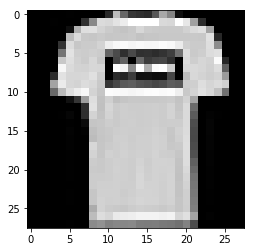

In [30]:
plt.imshow(trainX[1,:,:],cmap='gray')

### Build a neural Network with a cross entropy loss function and sgd optimizer in Keras. The output layer with 10 neurons as we have 10 classes.

In [41]:
model = Sequential()
model.add(Conv2D(filters = 64, kernel_size = (3, 3), activation = 'relu', input_shape = (28, 28, 1)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(filters = 128, kernel_size = (3, 3), activation = 'relu'))
model.add(MaxPooling2D((2, 2)))


model.add(Flatten())

model.add(Dense(256, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation = 'relu'))

model.add(Dense(10, activation = 'softmax'))

model.compile(optimizer = 'sgd', loss = 'categorical_crossentropy', metrics = ['accuracy'])

W0728 13:45:10.568296 140334971004800 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:74: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.

W0728 13:45:10.573584 140334971004800 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:517: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.

W0728 13:45:10.586721 140334971004800 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:4138: The name tf.random_uniform is deprecated. Please use tf.random.uniform instead.

W0728 13:45:10.624815 140334971004800 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:3976: The name tf.nn.max_pool is deprecated. Please use tf.nn.max_pool2d instead.

W0728 13:45:10.664413 140334971004800 deprecation_wrapp

### Execute the model using model.fit()

In [42]:
model.fit(X_train_P, Y_train, batch_size = 32, epochs = 10, validation_data = (X_test_P, Y_test))

W0728 13:45:50.152255 140334971004800 deprecation.py:323] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/math_grad.py:1250: add_dispatch_support.<locals>.wrapper (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 17s 280us/step - loss: 1.3674 - acc: 0.4724 - val_loss: 0.7490 - val_acc: 0.7107
Epoch 2/10
60000/60000 [==============================] - 9s 152us/step - loss: 0.7591 - acc: 0.7079 - val_loss: 0.5826 - val_acc: 0.7716
Epoch 3/10
60000/60000 [==============================] - 9s 155us/step - loss: 0.6306 - acc: 0.7624 - val_loss: 0.5224 - val_acc: 0.8033
Epoch 4/10
60000/60000 [==============================] - 9s 151us/step - loss: 0.5729 - acc: 0.7875 - val_loss: 0.4889 - val_acc: 0.8166
Epoch 5/10
60000/60000 [==============================] - 9s 151us/step - loss: 0.5316 - acc: 0.8048 - val_loss: 0.4592 - val_acc: 0.8254
Epoch 6/10
60000/60000 [==============================] - 9s 152us/step - loss: 0.5013 - acc: 0.8170 - val_loss: 0.4466 - val_acc: 0.8339
Epoch 7/10
60000/60000 [==============================] - 9s 154us/step - loss: 0.4762 - acc: 0.8269 - val_loss: 0.4135 -

### In the above Neural Network model add Batch Normalization layer after the input layer and repeat the steps.

### Execute the model

In [43]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 26, 26, 64)        640       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 13, 13, 64)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 11, 11, 128)       73856     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 5, 5, 128)         0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 3200)              0         
_________________________________________________________________
dense_1 (Dense)              (None, 256)               819456    
_________________________________________________________________
dropout_1 (Dropout)          (None, 256)               0         
__________

### Customize the learning rate to 0.001 in sgd optimizer and run the model

### Build the Neural Network model with 3 Dense layers with 100,100,10 neurons respectively in each layer. Use cross entropy loss function and singmoid as activation in the hidden layers and softmax as activation function in the output layer. Use sgd optimizer with learning rate 0.03.

## Review model

### Run the model

In [0]:
y_predictions = model.predict_classes(X_test_P)

In [0]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_predictions))